## Are We Alone in Space?
### Analyzing NASA’s Exoplanet Data with Python

---

In this project, we’ll explore relationships in real scientific data from NASA’s Exoplanet Archive.

Our goal is to practice exploratory data analysis (EDA): visualizing data, computing basic metrics, and interpreting patterns carefully.

---


### Goals

**1. Load the Data**  

**2. Practice Pure Python Skills**  

**3. Plot Relationships**  

**4. Compute Descriptive Statistics**  



### Questions

These are some of the questions we will tackle:

**1. Planet Size vs. Planet Mass**  
Common sense would suggest that larger planets also have more mass, but this might not be the case for gas planets. We will explore this relationship.

**2. Discovery Year vs. Planet Size**  
Sometimes relationships between 2 variables are more complex. There appears to be a correlation between discovery year and planets size (as better instruments might enable the discovery of smaller planets). We will analyze whether this is true.

**3. Discovery Methods**  
Different discovery methods have been used over the years. We will assess which one of them has found the most planets.

---

## Column descriptions 
Below are the columns we use in the notebook and what they represent.

- **pl_name:** Planet name (string)
- **pl_rade:** Planet radius in Earth radii (float)
- **pl_bmasse:** Planet mass in Earth masses (float)
- **discoverymethod:** Discovery method (categorical — e.g., Transit, Radial Velocity)
- **hostname:** Host star name (string)
- **disc_year:** Discovery year (datetime)


---
## 1. Load Data
In this section we import libraries and load the dataset using `pandas`. We’ll display the first few rows and some basic information about the dataset.

In [16]:
import pandas as pd
import requests
import time
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path



# Run this line to load in the data
df = pd.read_csv(Path(r'udacity_exoplanet.csv'))

# Print out the first 5 rows to verify it was loaded correctly
df

,pl_name,pl_rade,pl_bmasse,pl_orbper,discoverymethod,hostname,disc_year
0,55 Cnc e,1.933500,8.117035,0.736546,Radial Velocity,55 Cnc,2004
1,AU Mic b,4.070000,17.000000,8.463080,Transit,AU Mic,2020
2,AU Mic c,2.790000,13.600000,18.859018,Transit,AU Mic,2021
3,BD+20 594 b,2.355454,19.274050,41.685500,Transit,BD+20 594,2016
4,BD-14 3065 b,21.150600,3932.000000,4.288971,Transit,BD-14 3065 A,2024
...,...,...,...,...,...,...,...
1648,XO-7 b,15.389957,225.499819,2.864140,Transit,XO-7,2019
1649,ZTF J1230-2655 b,13.787046,7024.007795,0.235978,Transit,ZTF J1230-2655,2025
1650,ZTF J1828+2308 b,11.130518,6356.568140,0.112007,Transit,ZTF J1828+2308,2025
1651,bet Pic b,17.647425,3146.517000,7955.000000,Imaging,bet Pic,2008


## 2. Inspect the DataFrame

In [17]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1653, 7)
        pl_name    pl_rade    pl_bmasse  pl_orbper  discoverymethod  \
0      55 Cnc e   1.933500     8.117035   0.736546  Radial Velocity   
1      AU Mic b   4.070000    17.000000   8.463080          Transit   
2      AU Mic c   2.790000    13.600000  18.859018          Transit   
3   BD+20 594 b   2.355454    19.274050  41.685500          Transit   
4  BD-14 3065 b  21.150600  3932.000000   4.288971          Transit   

       hostname  disc_year  
0        55 Cnc       2004  
1        AU Mic       2020  
2        AU Mic       2021  
3     BD+20 594       2016  
4  BD-14 3065 A       2024  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1653 non-null   object 
 1   pl_rade          1653 non-null   float64
 2   pl_bmasse        1653 non-null   float64
 3   pl_orbper        1653 non-null   float64
 4   di

## 3. Examine Numeric Summaries



In [18]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.std(numeric_only=True)
df.min(numeric_only=True)
df.max(numeric_only=True)
df.sum(numeric_only=True)

pl_rade      1.300259e+04
pl_bmasse    5.837503e+05
pl_orbper    4.163603e+08
disc_year    3.334987e+06
dtype: float64

## 4. Create a Sorted List of Unique Planet and Host Star Names


In [19]:
# Convert the pl_name column into a plain Python list
planet_list = list(df["pl_name"])

# Remove duplicates using a set, then sort the results into a list
unique_planets = sorted(set(planet_list))

# Print the total number of unique planets
print("Total unique planets:", len(unique_planets))

# Print the first 20 unique planet names
print("First 20 unique planet names:")
for planet in unique_planets[:20]:
    print(planet)

Total unique planets: 1653
First 20 unique planet names:
55 Cnc e
AU Mic b
AU Mic c
BD+20 594 b
BD-14 3065 b
CFHTWIR-Oph 98 b
COCONUTS-2 b
CoRoT-1 b
CoRoT-10 b
CoRoT-11 b
CoRoT-12 b
CoRoT-13 b
CoRoT-14 b
CoRoT-16 b
CoRoT-17 b
CoRoT-18 b
CoRoT-19 b
CoRoT-2 b
CoRoT-20 b
CoRoT-21 b


In [20]:
# Convert the hostname column into a plain Python list
host_list = list(df["hostname"])

# Remove duplicates and sort the host star names
unique_hosts = sorted(set(host_list))

# Print the total number of unique host stars
print("Total unique host stars:", len(unique_hosts))

# Print a small sample (first 20) of the unique host star names
print("First 20 unique host star names:")
for host in unique_hosts[:20]:
    print(host)

Total unique host stars: 1272
First 20 unique host star names:
55 Cnc
AU Mic
BD+20 594
BD-14 3065 A
CFHTWIR-Oph 98 A
COCONUTS-2 A
CoRoT-1
CoRoT-10
CoRoT-11
CoRoT-12
CoRoT-13
CoRoT-14
CoRoT-16
CoRoT-17
CoRoT-18
CoRoT-19
CoRoT-2
CoRoT-20
CoRoT-21
CoRoT-22


## 5. Which THREE host stars have the MOST known planets?

In [21]:
# Count planets for each host star using a dictionary
host_counts = {}

for host in df["hostname"]:
    if host in host_counts:
        host_counts[host] += 1
    else:
        host_counts[host] = 1

# Convert the dictionary into a list of (star, planet_count) pairs
host_list = list(host_counts.items())

# Sort the list by planet count (highest first)
host_list = sorted(host_list, key=lambda x: x[1], reverse=True)

# Select the top three stars and print the results
top_three = host_list[:3]

print("Top 3 host stars with the most known planets:")
for star, planet_count in top_three:
    print(star, "-", planet_count, "planets")

Top 3 host stars with the most known planets:
TRAPPIST-1 - 7 planets
HD 110067 - 6 planets
K2-138 - 6 planets


## 6. Visual Inspection

### Histogram of planet radii

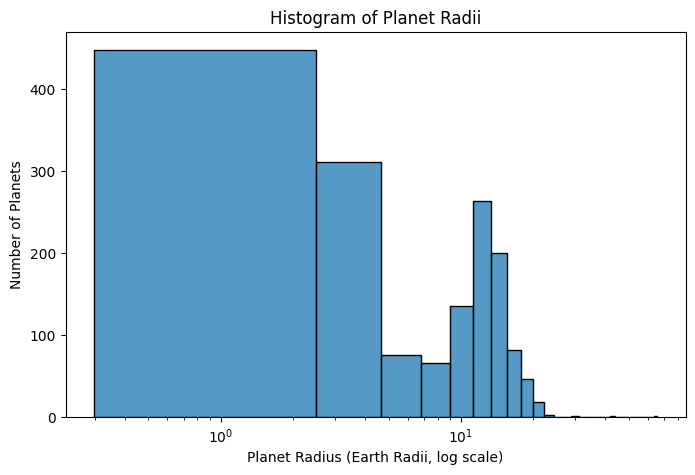

In [22]:
# Create the histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["pl_rade"].dropna(), bins=30)

# Use a log scale if the distribution is highly skewed
plt.xscale("log")

# Add title and axis labels
plt.title("Histogram of Planet Radii")
plt.xlabel("Planet Radius (Earth Radii, log scale)")
plt.ylabel("Number of Planets")

plt.show()

### Bar Chart of Top Discovery Methods 
#### Exoplanet Detection Methods include

* **Transit Photometry:** Detects periodic dips in a star’s brightness as a planet passes in front of it. It is highly sensitive to small, close-orbiting planets and can determine their size and density. Used by missions such as Kepler, TESS, and CHEOPS.

* **Radial Velocity:** Detects the gravitational wobble a planet induces in its host star through Doppler shifts in the star’s spectrum. It is particularly effective for detecting massive, close-orbiting planets and led to the discovery of 51 Pegasi b in 1995.

* **Imaging:*** Uses advanced telescopes and instruments to capture light from exoplanets and their surrounding systems. It can reveal planets by detecting their emitted or reflected light, particularly for large, young, and distant planets whose light can be separated from their host star.

* **Timing Variations:** Detects gravitational interactions between planets by measuring changes in predictable events, such as planetary transits, stellar eclipses, or stellar pulses. These variations can reveal otherwise unseen planets.

* **Orbital Brightness Modulation:** Detects periodic changes in a star system’s brightness caused by a planet’s orbit, including reflected light, thermal emission, and relativistic beaming. Unlike transit photometry, the planet does not need to pass in front of its star.


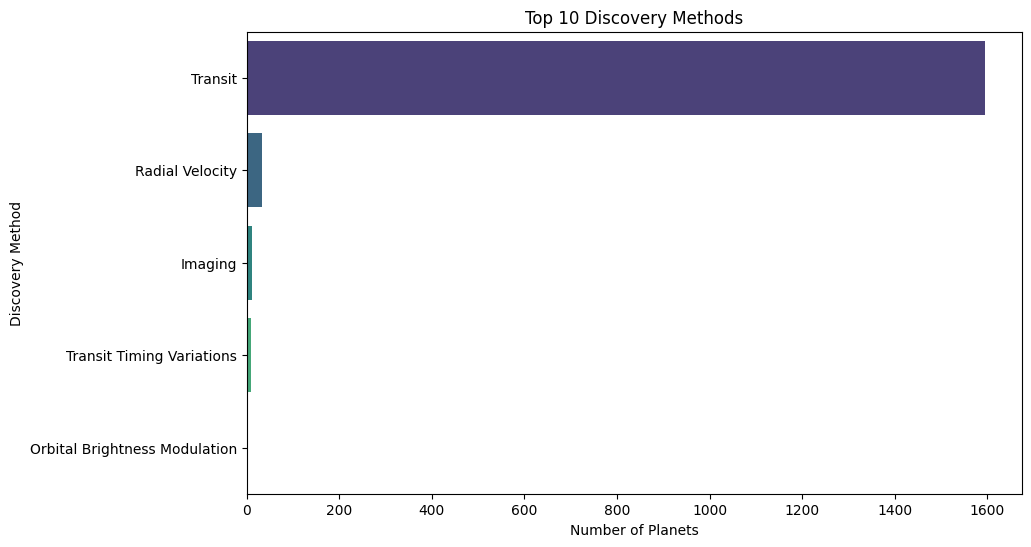

In [23]:
# Count discovery methods using basic Python
method_counts = {}

for method in df["discoverymethod"].dropna():
    if method in method_counts:
        method_counts[method] += 1
    else:
        method_counts[method] = 1

# Sort by count (highest first) and keep the top 10
top_methods = sorted(method_counts.items(), key=lambda x: x[1], reverse=True)[:10]

# Separate into lists
methods = [item[0] for item in top_methods]
counts = [item[1] for item in top_methods]

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=methods, hue=methods, palette="viridis", legend=False)

# Add title and axis labels
plt.title("Top 10 Discovery Methods")
plt.xlabel("Number of Planets")
plt.ylabel("Discovery Method")

plt.show()

### Scatter plot of Radius vs. Mass

In [24]:
import hvplot.pandas

# Interactive scatter plot
df.hvplot.scatter(
    x="pl_rade",
    y="pl_bmasse",
    color="discoverymethod",   
    title="Planet Radius vs. Planet Mass",
    xlabel="Planet Radius (Earth Radii)",
    ylabel="Planet Mass (Earth Masses)",
    width=700,
    height=500
)

:Scatter   [pl_rade]   (pl_bmasse,discoverymethod)

### Boxplot of Orbital Periods

In [25]:
# Interactive boxplot plot
import hvplot.pandas

df.hvplot.box(
    y="pl_orbper",
    logy=True,
    title="Distribution of Exoplanet Orbital Periods",
    ylabel="Orbital Period (days)",
    xlabel="Exoplanets"
)

:BoxWhisker   (pl_orbper)

### Scatter plot of Radius vs. Discovery Year

In [26]:
# Interactive scatter plot
df.hvplot.scatter(
    x="pl_rade",
    y="disc_year",
    color="discoverymethod",
    title="Planet Radius vs. Discovery Year",
    xlabel="Planet Radius (Earth Radii)",
    ylabel="Discovery Year"
)

:Scatter   [pl_rade]   (disc_year,discoverymethod)

## 7. Variable Relationships and Statistics

### Correlation Matrix of Numeric Variables 

In [27]:
# Correlation Matrix of Numeric Variables
correlation_matrix = df[
    ["pl_rade", "pl_bmasse", "pl_orbper"]
].rename(columns={
    "pl_rade": "Planet Radius",
    "pl_bmasse": "Planet Mass",
    "pl_orbper": "Orbital Period"
}).corr()

correlation_matrix.style.background_gradient(cmap="coolwarm")

,Planet Radius,Planet Mass,Orbital Period
Planet Radius,1.000000,0.353901,0.020235
Planet Mass,0.353901,1.000000,0.059204
Orbital Period,0.020235,0.059204,1.000000


### Compute radius statistics by year

In [28]:
radius_stats = (
    df.groupby("disc_year")["pl_rade"]
      .agg(["mean", "median"])
      .sort_index()
)

radius_stats.head(10)

,mean,median
disc_year,,
1999,15.468420,15.468420
2001,11.242627,11.242627
2002,14.571700,14.571700
2004,9.886131,12.117000
2005,11.531903,12.532910
2006,12.700952,13.518054
2007,14.166143,14.751104
2008,13.961444,13.849042
2009,12.687245,13.332961


## 8. Interactive visualization of radius statistics over time

In [29]:
# Calculate mode for each year
mode = df.groupby("disc_year")["pl_rade"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

radius_stats["mode"] = mode

# Mean line
mean_plot = radius_stats.hvplot.line(
    x="disc_year",
    y="mean",
    label="Mean",
    color="blue",
    line_width=2,
    title="Planet Radius Statistics Over Discovery Years",
    xlabel="Discovery Year",
    ylabel="Planet Radius (Earth Radii)"
)

# Median line
median_plot = radius_stats.hvplot.line(
    x="disc_year",
    y="median",
    label="Median",
    color="green",
    line_width=2
)

# Mode line
mode_plot = radius_stats.hvplot.line(
    x="disc_year",
    y="mode",
    label="Mode",
    color="red",
    line_width=2
)

# Overlay the three interactive plots
mean_plot * median_plot * mode_plot

:Overlay
   .Curve.Mean   :Curve   [disc_year]   (mean)
   .Curve.Median :Curve   [disc_year]   (median)
   .Curve.Mode   :Curve   [disc_year]   (mode)

## 9.  3D Visualization: Exploring Planet Characteristics

In [30]:
import plotly.express as px

plot_df = df[
    (df["pl_rade"] > 0) &
    (df["pl_bmasse"] > 0) &
    (df["pl_orbper"] > 0)
].dropna(subset=["pl_rade", "pl_bmasse", "pl_orbper", "discoverymethod"])

# Create interactive 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x="pl_rade",
    y="pl_bmasse",
    z="pl_orbper",
    color="discoverymethod",
    title="Planet Characteristics by Discovery Method",
    labels={
        "pl_rade": "Planet Radius (Earth Radii)",
        "pl_bmasse": "Planet Mass (Earth Masses)",
        "pl_orbper": "Orbital Period (Days)",
        "discoverymethod": "Discovery Method"
    },
    log_x=True,
    log_y=True,
    log_z=True
)

# Adjust marker size
fig.update_traces(marker=dict(size=4))

fig.show()